# ProScore 完整评分卡建模流程

> **角色视角**：消费金融风控建模专家  
> **数据**：`tests/demo_scorecard_data.csv`（6000 行演示数据，潜变量驱动、Train/Test 区分度稳定；单元测试仍用 800 行 `test_data.csv`）  
> **目标**：构建可解释、可审计、可投产的逻辑回归评分卡

## 建模原则（评分卡行业惯例）

| 数据集 | 时间窗口 | 用途 |
|--------|----------|------|
| **Train** | 2020–2021（开发池 70%） | 分箱切点、WOE、LR 系数学习 |
| **Test** | 2020–2021（开发池 30%，随机分层） | 时间内验证、`ks_reduce` 过拟合惩罚 |
| **OOT** | 2022–2023 | **仅**最终评估与监控（按年拆分看趋势），不参与变量筛选 |

> **时间内** Test 与 Train 同属 2020–2021 开发池（随机分层）。OOT = 2022 起，用 `evaluate_by_period` + `ModelMonitor.track` 看逐年变化。


## 0. 环境准备

**建模思路**：安装/导入 ProScore 及依赖；定位项目根目录与测试数据路径（notebook 可在 `notebooks/` 或项目根目录运行）。


In [1]:
import sys
from pathlib import Path

# 定位项目根目录（须在 import proscore 之前）
_cwd = Path.cwd()
def _find_project_root() -> Path:
    for base in (_cwd, _cwd.parent):
        if (base / "tests" / "demo_scorecard_data.csv").exists():
            return base
        if (base / "tests" / "test_data.csv").exists():
            return base
    raise FileNotFoundError(
        "找不到 tests/demo_scorecard_data.csv，请先运行: python tests/generate_test_data.py"
    )

PROJECT_ROOT = _find_project_root()

_src = PROJECT_ROOT / "src"
if _src.is_dir() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

# 开发时若内核曾加载旧版 proscore，清缓存后重新导入
for _name in list(sys.modules):
    if _name == "proscore" or _name.startswith("proscore."):
        del sys.modules[_name]

import matplotlib.pyplot as plt
import pandas as pd

import proscore as ps
from proscore import viz
from proscore.binning import BinningProcess, bin_table_to_dataframe
from proscore.evaluate import evaluate, evaluate_by_period
from proscore.inspect import (
    correlation,
    detect,
    list_supported_estimators,
    quality,
    stability,
    stability_summary,
    vif,
)
from proscore.modeling import ScoreCard
from proscore.monitor import ModelMonitor
from proscore.report import ReportBuilder
from proscore.selection import Filter, StepwiseSelector, assess_screen
from proscore.transform import WOETransformer
from proscore.utils import load_presets

_demo = PROJECT_ROOT / "tests" / "demo_scorecard_data.csv"
DATA_PATH = _demo if _demo.exists() else PROJECT_ROOT / "tests" / "test_data.csv"
PRESETS_PATH = PROJECT_ROOT / "tests" / "variable_presets.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "bad_flag"
DATE_COL = "apply_date"

print(f"ProScore 版本: {ps.__version__}")
print(f"项目根目录: {PROJECT_ROOT}")
print(f"数据文件: {DATA_PATH.name} ({'演示集 6000 行' if DATA_PATH.name.startswith('demo') else '测试集 800 行'})")
print(f"quality 可用估计器: {list_supported_estimators()}")


ProScore 版本: 0.1.0
项目根目录: /Users/pro/Desktop/procardbot
数据文件: demo_scorecard_data.csv (演示集 6000 行)
quality 可用估计器: ['decisiontree', 'dt', 'tree']


## 1. 数据加载与时间切分

**建模思路**：
- 按**申请年份**切分 Train / Test / OOT，符合评分卡时间序列验证规范。
- `read()` 时校验三张表列名一致，避免后续 WOE 转换列不匹配。
- 分箱、WOE、LR **只在 Train 上 fit**；Test 用于逐步回归的过拟合监控；OOT 留到最后。


In [2]:
full_df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])

from sklearn.model_selection import train_test_split

# 开发池：2020–2021；时间内 Train/Test 随机分层；OOT：2022 起（含 2022、2023）
dev_pool = full_df[full_df[DATE_COL].dt.year <= 2021].copy()
oot_df = full_df[full_df[DATE_COL].dt.year >= 2022].copy()

train_df, test_df = train_test_split(
    dev_pool,
    test_size=0.30,
    stratify=dev_pool[TARGET],
    random_state=42,
)
train_df = train_df.copy()
test_df = test_df.copy()

# 建模特征列（排除目标与时间）
feature_cols = [c for c in full_df.columns if c not in (TARGET, DATE_COL)]
num_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(full_df[c])]
cat_features = [c for c in feature_cols if c not in num_features]

print("样本量与坏样本率：")
for name, df in [("Train", train_df), ("Test(in-time)", test_df)]:
    print(f"  {name:16s}: n={len(df):4d}, bad_rate={df[TARGET].mean():.2%}")
for year, g in oot_df.groupby(oot_df[DATE_COL].dt.year):
    print(f"  OOT {int(year)}       : n={len(g):4d}, bad_rate={g[TARGET].mean():.2%}")
print(f"  OOT (合计)      : n={len(oot_df):4d}, bad_rate={oot_df[TARGET].mean():.2%}")

train_df.head(3)


样本量与坏样本率：
  Train           : n=1878, bad_rate=18.42%
  Test(in-time)   : n= 805, bad_rate=18.51%
  OOT 2022       : n=1667, bad_rate=21.48%
  OOT 2023       : n=1650, bad_rate=21.33%
  OOT (合计)      : n=3317, bad_rate=21.40%


,apply_date,income,debt_ratio,age,utilization,credit_months,num_inquiries,education,employment_type,home_ownership,loan_purpose,bad_flag
4289,2021-05-02,34952.666139,0.229577,34.425948,15.492890,205.794631,0.0,high_school,salaried,mortgage,personal,0
1168,2021-10-09,35639.214529,0.305117,33.390730,35.318245,153.380410,2.0,master,salaried,own,personal,0
3184,2021-01-21,33449.156723,0.150673,56.261254,27.615158,154.875165,2.0,bachelor,unemployed,mortgage,mortgage,0


## 2. 数据探查（inspect）— 仅在 Train 上做统计

**建模思路**：探查在 Train 上完成；`quality(df_test=test_df)` 用 **时间内 Test** 看 PSI；若有 OOT 可在监控/评估看跨期。分类变量 AUC/KS 为空属正常。


In [3]:
# detect：变量质量总览（缺失、唯一值、分位数、与目标关联）
# special_values：将 -999 识别为收入类的特殊缺失编码
detect_result = detect(
    train_df,
    target=TARGET,
    special_values=[-999.0],
    max_categories=20,
)
detect_result


,variable,dtype,count,n_unique,missing,missing_pct,one_value_pct,special_pct,special_pct_valid,mean,std,min,p25,p50,p75,max,target_pearson,target_cramers_v
0,apply_date,other,1878,682,0,0.00,0.43,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,income,numeric,1878,1867,8,0.43,0.21,0.21,0.21,46117.9391,24563.1277,-999.00,29361.816482,40842.582499,57219.402076,250548.71546,-0.272494,NaN
2,debt_ratio,numeric,1878,1668,6,0.32,10.95,0.00,0.00,0.2279,0.1394,0.03,0.117427,0.220695,0.327189,0.71270,0.375116,NaN
3,age,numeric,1878,1827,0,0.00,2.24,0.00,0.00,44.0259,10.7877,21.00,36.350680,44.151044,51.342523,72.00000,0.203034,NaN
4,utilization,numeric,1878,1757,12,0.64,4.88,0.00,0.00,39.9864,23.4849,0.00,22.956984,38.869909,54.588343,100.00000,0.365486,NaN
5,credit_months,numeric,1878,1841,0,0.00,2.02,0.00,0.00,129.8728,56.5052,6.00,92.532500,130.177726,167.278195,339.92295,-0.320938,NaN
6,num_inquiries,categorical,1878,12,11,0.59,25.82,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.213232
7,education,categorical,1878,6,0,0.00,45.47,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.111249
8,employment_type,categorical,1878,4,12,0.64,58.74,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.117650
9,home_ownership,categorical,1878,4,0,0.00,42.97,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.078466


In [4]:
# quality：单变量 IV / AUC / KS（Train 上拟合）+ PSI（Train vs Test 分布）
# warn_insample_bias=True：提醒 AUC/KS 为样本内估计，仅供粗筛
quality_result = quality(
    train_df,
    target=TARGET,
    df_test=test_df,
    skip_columns=[DATE_COL],
    max_categories=20,
    estimator="dt",
    compute_ks=True,
    errors="raise",
    warn_insample_bias=True,
)
quality_result.sort_values("iv", ascending=False)


/var/folders/1g/17g_cnv164g4jqsl7qrjx89m0000gn/T/ipykernel_53120/1490933612.py:3: UserWarning: Single-variable AUC and KS are computed in-sample and are biased (optimistic) estimates. Use only for coarse screening, not for final feature selection.
  quality_result = quality(


,variable,dtype,iv,auc,ks,psi,missing_pct,n_unique
0,debt_ratio,numeric,1.312858,0.797358,0.00262,0.009272,0.32,1668
1,utilization,numeric,1.168049,0.778335,0.00000,0.015540,0.64,1757
2,credit_months,numeric,0.884836,0.754716,0.00000,0.007300,0.00,1841
3,income,numeric,0.840716,0.741874,0.00000,0.017060,0.43,1867
4,age,numeric,0.298676,0.657160,0.00000,0.015700,0.00,1827
5,num_inquiries,categorical,0.276840,NaN,NaN,0.029513,0.59,12
6,education,categorical,0.107121,NaN,NaN,0.009728,0.00,6
7,employment_type,categorical,0.080209,NaN,NaN,0.007573,0.64,4
8,home_ownership,categorical,0.038093,NaN,NaN,0.003384,0.00,4
9,loan_purpose,categorical,0.003474,NaN,NaN,0.003411,0.00,6


In [5]:
# stability：跨年度时序稳定性（在全量数据上按 year 分析）
full_for_stab = full_df.copy()
full_for_stab["year"] = full_for_stab[DATE_COL].dt.year

stability_result = stability(
    full_for_stab,
    target=TARGET,
    time_col="year",
    features=feature_cols,
    n_bins=5,
    bad_rate_trend_threshold=0.5,
    psi_warn_threshold=0.1,
)
# PSI 分布漂移 / 坏账率趋势 — 两列分开看
print("=== PSI 不稳定 (psi_flag=unstable) ===")
display(stability_result[stability_result["psi_flag"] == "unstable"].head(10))
print("=== 坏账率趋势异常 ===")
display(
    stability_result[
        stability_result["bad_rate_flag"].isin(["trending_up", "trending_down"])
    ].head(10)
)

# 透视表：每变量一行 + 末期 psi_flag / bad_rate_flag
stability_summary(stability_result, metric="bad_rate")


=== PSI 不稳定 (psi_flag=unstable) ===


,variable,time_period,n,bad_rate,bad_rate_change,psi_vs_first,psi_vs_prev,mean,std,psi_flag,bad_rate_flag


=== 坏账率趋势异常 ===


,variable,time_period,n,bad_rate,bad_rate_change,psi_vs_first,psi_vs_prev,mean,std,psi_flag,bad_rate_flag


/Users/pro/Desktop/procardbot/src/proscore/inspect/_stability.py:180: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = stability_result.pivot_table(


time_period,variable,2020,2021,2022,2023,latest_psi_flag,latest_bad_rate_flag
0,age,0.197059,0.17158,0.214757,0.213333,stable,stable
1,credit_months,0.197059,0.17158,0.214757,0.213333,stable,stable
2,debt_ratio,0.197059,0.17158,0.214757,0.213333,stable,stable
3,education,0.197059,0.17158,0.214757,0.213333,stable,stable
4,employment_type,0.197059,0.17158,0.214757,0.213333,stable,stable
5,home_ownership,0.197059,0.17158,0.214757,0.213333,stable,stable
6,income,0.197059,0.17158,0.214757,0.213333,stable,stable
7,loan_purpose,0.197059,0.17158,0.214757,0.213333,stable,stable
8,num_inquiries,0.197059,0.17158,0.214757,0.213333,stable,stable
9,utilization,0.197059,0.17158,0.214757,0.213333,stable,stable


In [6]:
# correlation + VIF：多重共线性诊断（Train 数值特征）
corr_matrix = correlation(train_df[num_features])
vif_result = vif(train_df[num_features])
vif_result


,variable,vif,flag
0,debt_ratio,3.5289,ok
1,utilization,3.2769,ok
2,credit_months,2.3131,ok
3,income,1.6083,ok
4,age,1.3401,ok
5,num_inquiries,1.1708,ok


## 3. 专家预设（Excel → 分箱单调性 + 逐步回归来源归属）

**建模思路**：业务专家在 Excel 中维护每个变量的：
- `monotonic`：WOE 趋势约束（increasing / decreasing / u / inverted_u）
- `special_values`：特殊值单独成箱（如 income 的 -999）
- `dimension`：变量归属维度，用于 Stepwise 同源竞争控制

> 需安装 `pip install proscore[excel]`


In [7]:
presets = load_presets(str(PRESETS_PATH))
print("feature_config 变量数:", len(presets.feature_config))
print("feature_belong 维度数:", len(presets.feature_belong))
presets.feature_config


feature_config 变量数: 6
feature_belong 维度数: 7


{'income': {'monotonic': 'decreasing', 'special_values': [np.float64(-999.0)]},
 'debt_ratio': {'monotonic': 'increasing'},
 'age': {'monotonic': 'u'},
 'utilization': {'monotonic': 'increasing'},
 'credit_months': {'monotonic': 'decreasing'},
 'num_inquiries': {'monotonic': 'increasing'}}

## 4. 分箱（BinningProcess）— 仅在 Train 上学习切点

**建模思路**：
- 先用 `BinningProcess` 对**全部候选特征**分箱，产出 `bin_table_` 供 Filter 计算真实 IV/PSI。
- `feature_config` 注入专家预设的单调性与特殊值。
- `adjust_shape=True`：无监督分箱后自动调整至预设趋势。
- 分箱方法默认卡方（chi），连续变量 5 箱，类别变量 `woe_per_value`。


In [8]:
binning_process = BinningProcess(
    feature_config=presets.feature_config,
    default_method="chi",
    default_n_bins=5,
    min_bin_pct=0.05,
    min_woe_diff=0.1,
    adjust_shape=True,
    categorical_mode="woe_per_value",
    min_nobs=30,
)
binning_process.fit(train_df[feature_cols + [TARGET]], y=TARGET)

iv_table = binning_process.iv_
display(iv_table.sort_values("iv", ascending=False))

# 全变量分箱明细表 + 单变量 bad_rate 图
bin_summary = bin_table_to_dataframe(binning_process.bin_table_)
display(bin_summary.head(20))


/Users/pro/Desktop/procardbot/src/proscore/binning/_binning.py:202: UserWarning: Variable 'age': final bins trend is increasing (code=1), but monotonic='u' (U-shape) was preset. (data may not support the requested shape)
  bt = self._fit_one(X[col], y_series, col, skip_vals)
/Users/pro/Desktop/procardbot/src/proscore/binning/_binning.py:202: UserWarning: Variable 'num_inquiries': final bins trend is none (code=0), but monotonic='increasing' (increasing) was preset. (data may not support the requested shape)
  bt = self._fit_one(X[col], y_series, col, skip_vals)


,variable,iv
0,debt_ratio,1.286305
1,utilization,1.137065
2,credit_months,0.895902
3,income,0.840484
4,num_inquiries,0.276533
5,age,0.261346
6,education,0.107122
7,employment_type,0.080713
8,home_ownership,0.038093
9,loan_purpose,0.003474


,variable,bin_no,bin_label,count,count_bad,count_good,bad_rate,woe,iv,iv_total,method,monotonic,trend_match
0,income,0,"(-inf, 18501.3330]",112,50,62,0.446429,1.272779,0.132418,0.840484,chi,2,True
1,income,1,"(18501.3330, 33760.9187]",523,170,353,0.325048,0.757221,0.197568,0.840484,chi,2,True
2,income,2,"(33760.9187, 53055.3999]",671,96,575,0.143070,-0.302131,0.029569,0.840484,chi,2,True
3,income,3,"(53055.3999, 62096.5607]",187,14,173,0.074866,-1.026344,0.074371,0.840484,chi,2,True
4,income,4,"(62096.5607, inf]",373,12,361,0.032172,-1.916081,0.385051,0.840484,chi,2,True
5,income,5,-999.0,4,3,1,0.750000,2.586503,0.020738,0.840484,chi,2,True
6,income,6,missing,8,1,7,0.125000,-0.458020,0.000769,0.840484,chi,2,True
7,debt_ratio,0,"(-inf, 0.1223]",487,11,476,0.022587,-2.000000,0.557826,1.286305,chi,1,True
8,debt_ratio,1,"(0.1223, 0.2100]",412,24,388,0.058252,-1.295061,0.238161,1.286305,chi,1,True
9,debt_ratio,2,"(0.2100, 0.2464]",149,26,123,0.174497,-0.066197,0.000340,1.286305,chi,1,True


In [9]:
# 查看单个变量分箱详情（WOE、坏账率、趋势匹配）
demo_var = "income" if "income" in binning_process.bin_table_ else list(binning_process.bin_table_.keys())[0]
bt_demo = binning_process.bin_table_[demo_var]
print(f"{demo_var}: IV={bt_demo.iv_total:.4f}, trend={bt_demo.monotonic}, match={bt_demo.trend_match}")
bt_demo


income: IV=0.8405, trend=2, match=True


BinTable(var='income', bins=[BinRecord(bin_no=0, min_val=-inf, max_val=18501.332980977626, count=112, count_bad=50, count_good=62, bad_rate=0.44642857142857145, woe=1.272779, iv=0.132418, bin_label='(-inf, 18501.3330]'), BinRecord(bin_no=1, min_val=18501.332980977626, max_val=33760.91869200635, count=523, count_bad=170, count_good=353, bad_rate=0.32504780114722753, woe=0.757221, iv=0.197568, bin_label='(18501.3330, 33760.9187]'), BinRecord(bin_no=2, min_val=33760.91869200635, max_val=53055.399878619646, count=671, count_bad=96, count_good=575, bad_rate=0.14307004470938897, woe=-0.302131, iv=0.029569, bin_label='(33760.9187, 53055.3999]'), BinRecord(bin_no=3, min_val=53055.399878619646, max_val=62096.56070790648, count=187, count_bad=14, count_good=173, bad_rate=0.0748663101604278, woe=-1.026344, iv=0.074371, bin_label='(53055.3999, 62096.5607]'), BinRecord(bin_no=4, min_val=62096.56070790648, max_val=inf, count=373, count_bad=12, count_good=361, bad_rate=0.032171581769437, woe=-1.91608

## 5. 预筛选 — 粗筛 + 精筛（两阶段 Filter）

**建模思路**（与链式 `prefilter → bin → refine` 一致）：
1. **粗筛**（分箱前）：缺失 | 单值 | 相关 | VIF | (可选 AUC)，不做 IV/PSI
2. **分箱**（§4 已完成）
3. **精筛**（分箱后）：IV 区间 | PSI（Train vs 时间内 Test）


In [10]:
prefilter = Filter(
    max_missing_rate=0.50,
    max_one_value_rate=0.95,
    iv_range=None,
    max_psi=None,
    min_auc=None,  # 粗筛不做 AUC（小样本下 0.52 易误杀全部数值变量）
    max_corr=0.75,
    max_vif=10.0,
)
prefilter.fit(train_df[num_features], train_df[TARGET])
coarse_num = prefilter.support_
coarse_gate = assess_screen(coarse_num, stage="粗筛", n_candidates=len(num_features))
print(coarse_gate.message or f"粗筛保留数值特征 ({len(coarse_num)}): {coarse_num}")

feature_filter = None
if coarse_gate.ok:
    feature_filter = Filter(
        iv_range=(0.02, None),
        max_psi=0.25,
        max_corr=None,
        max_vif=None,
        min_auc=None,
        max_missing_rate=1.0,
        max_one_value_rate=1.0,
    )
    feature_filter.fit(
        train_df[coarse_num],
        train_df[TARGET],
        X_test=test_df[coarse_num],
        bin_table=binning_process.bin_table_,
    )
    filtered_num = feature_filter.support_
else:
    filtered_num = []

model_features = filtered_num + cat_features
model_gate = assess_screen(
    model_features,
    stage="建模候选池",
    n_candidates=len(num_features) + len(cat_features),
)
PIPELINE_HALT = not model_gate.ok
print(model_gate.message or f"精筛数值 ({len(filtered_num)}): {filtered_num}")
print(f"建模候选池 ({len(model_features)}): {model_features}")
if PIPELINE_HALT:
    print(">>> 无可建模变量，后续 WOE/回归/评分卡步骤请跳过；仍可生成探查+筛选报告。")
prefilter.quality_ if feature_filter is None else feature_filter.quality_


粗筛保留数值特征 (5): ['income', 'debt_ratio', 'age', 'credit_months', 'num_inquiries']
精筛数值 (5): ['income', 'debt_ratio', 'age', 'credit_months', 'num_inquiries']
建模候选池 (9): ['income', 'debt_ratio', 'age', 'credit_months', 'num_inquiries', 'education', 'employment_type', 'home_ownership', 'loan_purpose']


,feature,missing_rate,one_value_rate,iv,iv_source,selected,dropped,reason
0,income,0.004260,0.002139,0.840484,bin_table,True,False,
1,debt_ratio,0.003195,0.109509,1.286305,bin_table,True,False,
2,age,0.000000,0.022364,0.261346,bin_table,True,False,
3,credit_months,0.000000,0.020234,0.895902,bin_table,True,False,
4,num_inquiries,0.005857,0.258168,0.276533,bin_table,True,False,


## 6. WOE 转换 — fit on Train, transform all sets

**建模思路**：
- `unseen_strategy="worst"`：OOT/Test 中出现训练集未见类别时赋最差 WOE（保守策略）。
- 仅用 Filter 后保留特征的分箱表。


In [11]:
bin_table_final = {k: v for k, v in binning_process.bin_table_.items() if k in model_features}

if PIPELINE_HALT:
    print("跳过 WOE / 逐步回归 / 评分卡（无可建模变量）。")
else:
    woe_transformer = WOETransformer(unseen_strategy="worst")
    woe_transformer.fit(bin_table_final)
    train_woe = woe_transformer.transform(train_df[model_features])
    train_woe[TARGET] = train_df[TARGET].values
    test_woe = woe_transformer.transform(test_df[model_features])
    test_woe[TARGET] = test_df[TARGET].values
    oot_woe = woe_transformer.transform(oot_df[model_features])
    oot_woe[TARGET] = oot_df[TARGET].values
    train_woe.head()


## 7. 逐步回归（StepwiseSelector）— Train 拟合 + Test 过拟合惩罚

**建模思路**：
- **目标函数 `ks_reduce`**：最大化 Train KS，同时惩罚 Train-Test KS 差距（过拟合）。
- **五重约束**：p 值、系数符号、VIF、相关系数、来源归属（`feature_belong`）。
- **perturbation**：陷入局部最优时随机扰动重搜。
- **force_fill**：变量不足时放宽约束凑满 `n_min`。
- OOT **不参与**本步骤。

> `feature_belong` 需裁剪为当前候选池内存在的变量。


In [12]:
# 裁剪来源归属至候选池（Filter 可能剔除部分数值变量）
feature_belong = {
    src: [f for f in feats if f in model_features]
    for src, feats in presets.feature_belong.items()
}
feature_belong = {k: v for k, v in feature_belong.items() if v}
feature_belong


{'还款能力': ['income'],
 '负债水平': ['debt_ratio'],
 '个人信息': ['age', 'education', 'employment_type'],
 '信用历史': ['credit_months'],
 '查询行为': ['num_inquiries'],
 '资产状况': ['home_ownership'],
 '贷款特征': ['loan_purpose']}

In [13]:
if PIPELINE_HALT:
    stepwise = None
    final_features = []
else:
    stepwise = StepwiseSelector(
        pvalue_threshold=0.05,
        coef_sign="positive",
        vif_threshold=10.0,
        corr_threshold=0.8,
        feature_belong=feature_belong,
        belong_max_pct=0.5,
        perturbation=True,
        perturbation_pct=0.15,
        perturbation_add=2,
        max_iter_round=20,
        max_iter_time=300,
        same_round_exit=3,
        r=0.8,
        objective="ks_reduce",
        goal_threshold=0.005,
        n_min=4,
        n_max=8,
        force_fill=True,
    )
    stepwise.fit(
        train_woe,
        train_woe[TARGET],
        candidates=model_features,
        X_test=test_woe,
        y_test=test_woe[TARGET],
    )
    final_features = stepwise.support_
    print("最终入模变量:", final_features)
    print("最优轮次性能:", stepwise.best_performance_)


最终入模变量: ['debt_ratio', 'income', 'credit_months', 'home_ownership', 'employment_type']
最优轮次性能: {'trn_ks': 0.5296903062225509, 'test_ks': 0.521853003764937, 'ks_reduce': 0.007837302457613826, 'trn_auc': 0.8177011802170272, 'test_auc': 0.7974914061221148, 'auc_reduce': 0.020209774094912425, 'model_vars': ['debt_ratio', 'income', 'credit_months', 'home_ownership', 'employment_type']}


## 8. 评分卡建模（ScoreCard）— 仅在 Train WOE 上拟合 LR

**建模思路**：
- 标准评分卡刻度：`odds=20`、`pdo=20`、`base_score=600`。
- 分值公式：`points = -pdo/ln(2) × coef × woe`（**高分 = 低风险**）；客户总分不应为负。
- 将 LR 系数转换为每箱得分，生成可交付评分卡表。


In [14]:
scorecard = ScoreCard(odds=20, pdo=20, base_score=600)
scorecard.fit(train_woe, y=TARGET, features=final_features)
scorecard.scorecard(bin_table_final)

score_table = scorecard.score_table_
score_table


,variable,bin_label,bin_no,count,bad_rate,woe,coef,points,is_extra
0,debt_ratio,"(-inf, 0.1223]",0,487,0.022587,-2.000000,0.687840,39.69,False
1,debt_ratio,"(0.1223, 0.2100]",1,412,0.058252,-1.295061,0.687840,25.70,False
2,debt_ratio,"(0.2100, 0.2464]",2,149,0.174497,-0.066197,0.687840,1.31,False
3,debt_ratio,"(0.2464, 0.3414]",3,412,0.254854,0.415003,0.687840,-8.24,False
4,debt_ratio,"(0.3414, inf]",4,412,0.434466,1.224238,0.687840,-24.30,False
5,debt_ratio,missing,5,6,0.166667,-0.121547,0.687840,2.41,True
6,income,"(-inf, 18501.3330]",0,112,0.446429,1.272779,0.425712,-15.63,False
7,income,"(18501.3330, 33760.9187]",1,523,0.325048,0.757221,0.425712,-9.30,False
8,income,"(33760.9187, 53055.3999]",2,671,0.143070,-0.302131,0.425712,3.71,False
9,income,"(53055.3999, 62096.5607]",3,187,0.074866,-1.026344,0.425712,12.61,False


## 9. 模型评估 — Train / Test / OOT 三组指标

**建模思路**：
- **Train**：样本内表现（通常最优）。
- **Test**：时间内样本外，检验过拟合。
- **OOT**：时间外最终验证，模拟上线后表现。
- `ks_reduce = trn_ks - test_ks`：过拟合程度量化。


In [15]:
eval_result = evaluate(
    scorecard.model_,
    train_woe[final_features],
    train_woe[TARGET],
    X_test=test_woe[final_features],
    y_test=test_woe[TARGET],
    X_oot=oot_woe[final_features],
    y_oot=oot_woe[TARGET],
    features=final_features,
    n_bins=10,
    threshold=0.5,
)

metrics = {k: eval_result[k] for k in eval_result if k != "score_table"}
display(pd.Series(metrics))

# 分年度 OOT（2022 / 2023 …）
oot_periods = {
    str(int(yr)): (oot_woe.loc[g.index, final_features], g[TARGET])
    for yr, g in oot_df.groupby(oot_df[DATE_COL].dt.year)
}
oot_period_eval = evaluate_by_period(
    scorecard.model_,
    train_woe[final_features],
    train_woe[TARGET],
    periods=oot_periods,
    features=final_features,
)
oot_period_eval


trn_ks                                                 0.528385
trn_auc                                                0.817701
trn_acc                                                0.816294
model_vars    [debt_ratio, income, credit_months, home_owner...
test_ks                                                0.517894
test_auc                                               0.797491
test_acc                                               0.801242
ks_reduce                                              0.010491
ks_rel_gap                                             0.019855
psi                                                    0.021487
oot_ks                                                  0.52533
oot_auc                                                 0.79701
oot_acc                                                0.776002
dtype: object

,period,n,bad_rate,ks,auc,acc,psi_score,ks_decay,auc_decay
0,2022,1667,0.214757,0.549603,0.803360,0.773245,0.043457,-0.040156,0.017539
1,2023,1650,0.213333,0.503226,0.790453,0.778788,0.069805,0.047614,0.033322


In [16]:
# 分数分布对比表（Train vs Test 分箱坏账率）
eval_result["score_table"]


,bin,count,good,bad,bad_rate,pct,cum_good_pct,cum_bad_pct,ks
0,"(-inf, 0.0184]",85,82,3,0.0353,10.56,12.50,2.01,10.49
1,"(0.0184, 0.0273]",87,83,4,0.0460,10.81,25.15,4.70,20.45
2,"(0.0273, 0.0422]",64,62,2,0.0312,7.95,34.60,6.04,28.56
3,"(0.0422, 0.0622]",65,64,1,0.0154,8.07,44.36,6.71,37.65
4,"(0.0622, 0.1181]",106,101,5,0.0472,13.17,59.76,10.07,49.69
5,"(0.1181, 0.1798]",87,71,16,0.1839,10.81,70.58,20.81,49.77
6,"(0.1798, 0.2656]",85,63,22,0.2588,10.56,80.18,35.57,44.61
7,"(0.2656, 0.3568]",73,45,28,0.3836,9.07,87.04,54.36,32.68
8,"(0.3568, 0.4710]",80,42,38,0.4750,9.94,93.45,79.87,13.58
9,"(0.4710, inf]",73,43,30,0.4110,9.07,100.00,100.00,0.00


## 10. 可视化诊断（viz）

**建模思路**：KS/ROC 曲线、分箱 WOE 图、分数分布图，用于模型评审与监管材料。


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


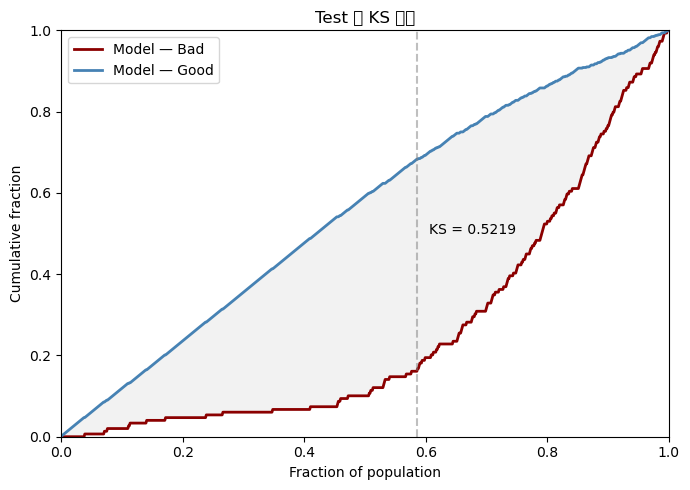

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


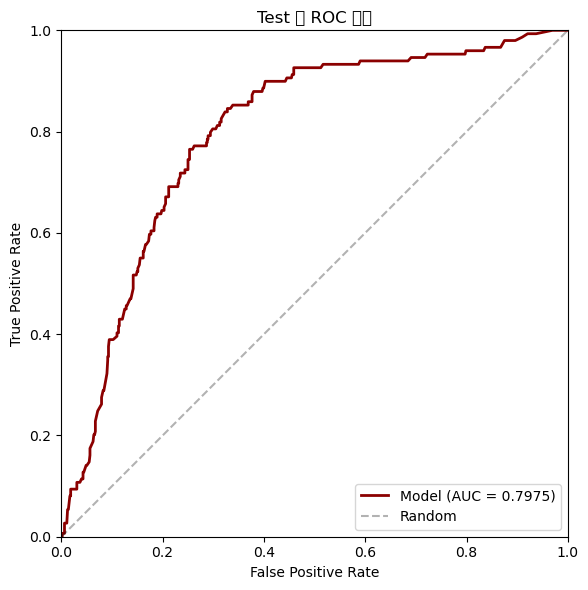

In [17]:
import statsmodels.api as sm

# 预测概率（用于 KS/ROC）
X_test_const = sm.add_constant(test_woe[final_features], has_constant="add")
prob_test = scorecard.model_.predict(X_test_const)

fig_ks = viz.plot_ks(test_woe[TARGET].values, prob_test)
plt.title("Test 集 KS 曲线")
plt.show()

fig_roc = viz.plot_roc(test_woe[TARGET].values, prob_test)
plt.title("Test 集 ROC 曲线")
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


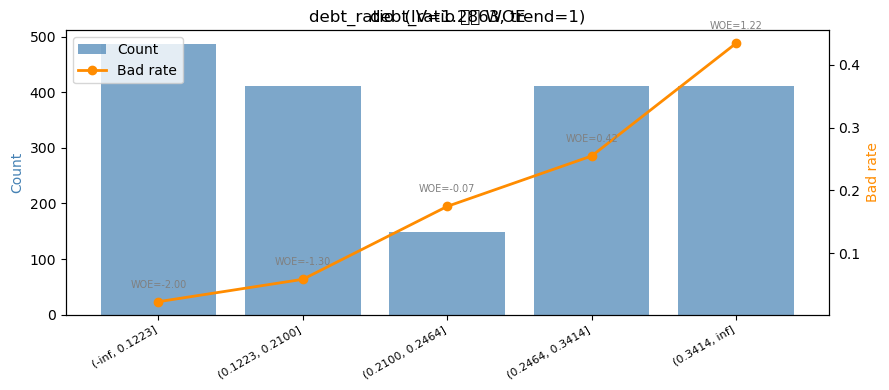

In [18]:
# 分箱 WOE 图（以 debt_ratio 为例，若在入模变量中则换用入模变量）
plot_var = "debt_ratio" if "debt_ratio" in bin_table_final else list(bin_table_final.keys())[0]
fig_bin = viz.plot_binning(bin_table_final[plot_var])
plt.title(f"{plot_var} 分箱 WOE")
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


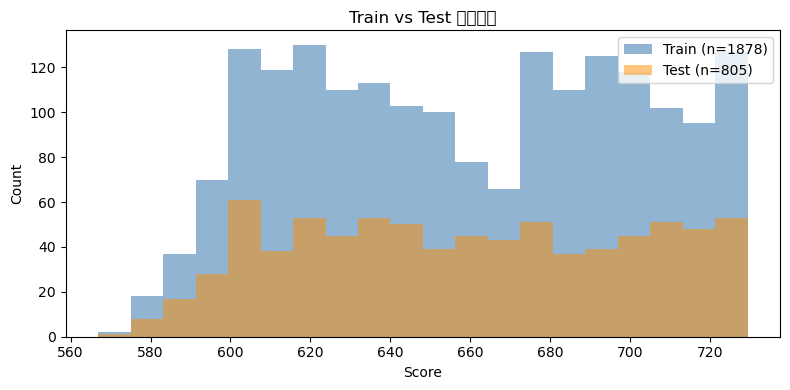

In [19]:
train_scores = scorecard.predict(train_woe[final_features]).values
test_scores = scorecard.predict(test_woe[final_features]).values

fig_dist = viz.plot_score_distribution(train_scores, test_scores)
plt.title("Train vs Test 分数分布")
plt.show()


## 11. 链式 API 对照（ProScore 一键流程）

**建模思路**：链式 API 与模块化一致：`detect → prefilter → bin → refine → transform → select → fit → scorecard → evaluate`。


In [20]:
# 链式 API：与模块化相同顺序，跑通至 evaluate
p_chain = (
    ps.ProScore()
    .read(
        train=train_df.drop(columns=[DATE_COL]),
        test=test_df.drop(columns=[DATE_COL]),
        oot=oot_df.drop(columns=[DATE_COL]),
        target=TARGET,
    )
    .detect(special_values=[-999.0])
    .prefilter(
        max_missing_rate=0.50,
        iv_range=None,
        max_psi=None,
        min_auc=None,
        max_corr=0.75,
        max_vif=10.0,
    )
    .bin(method="chi", n_bins=5, adjust_shape=True)
    .refine(iv_range=(0.02, None), max_psi=0.25)
    .transform(unseen_strategy="worst")
    .select(
        method="stepwise",
        objective="ks_reduce",
        n_min=4,
        n_max=8,
        force_fill=True,
        max_iter_round=15,
    )
    .fit(odds=20, pdo=20, base_score=600)
    .scorecard()
    .evaluate()
)

print("链式 API 入模变量:", p_chain.support_)
print("模块化路径入模变量:", final_features)
print("链式 evaluate:", {k: p_chain.eval_result[k] for k in p_chain.eval_result if k != "score_table"})


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/p

链式 API 入模变量: ['debt_ratio', 'num_inquiries', 'age', 'education']
模块化路径入模变量: ['debt_ratio', 'income', 'credit_months', 'home_ownership', 'employment_type']
链式 evaluate: {'trn_ks': 0.485681, 'trn_auc': 0.802425, 'trn_acc': 0.814696, 'model_vars': ['debt_ratio', 'num_inquiries', 'age', 'education'], 'test_ks': 0.4548, 'test_auc': 0.775853, 'test_acc': 0.807453, 'ks_reduce': 0.030881, 'ks_rel_gap': 0.063583, 'psi': 0.004481, 'oot_ks': 0.466211, 'oot_auc': 0.782242, 'oot_acc': 0.78173}


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(sel

## 12. 模型监控（ModelMonitor）— 基线 + 分年 OOT 追踪

**建模思路**：
- 以 Train 分数/特征分布为**基线**。
- 对 OOT **按年**（2022、2023…）分别 `track()`，观察 PSI / KS 衰减的跨年变化。
- `monitor.history` 汇总各期结果。


In [21]:
monitor = ModelMonitor(
    baseline_scores=train_scores,
    baseline_y=train_woe[TARGET].values,
    baseline_features=train_df[final_features],
    baseline_bins=bin_table_final,
    psi_warn=0.10,
    psi_critical=0.25,
    ks_decay_warn=0.15,
    ks_decay_critical=0.30,
    score_bins=20,
)

oot_track_rows = []
for year, oot_year in oot_df.groupby(oot_df[DATE_COL].dt.year):
    yr = int(year)
    idx = oot_year.index
    oot_year_woe = oot_woe.loc[idx, final_features]
    oot_year_scores = scorecard.predict(oot_year_woe).values
    res = monitor.track(
        period=f"{yr}-OOT",
        scores=oot_year_scores,
        y_true=oot_year[TARGET].values,
        features=oot_year[final_features],
    )
    oot_track_rows.append({
        "period": res.period,
        "status": res.status,
        "ks": res.ks,
        "auc": res.auc,
        "psi_score": res.psi_score,
        "ks_decay": res.ks_decay,
        "n": res.n_samples,
        "bad_rate": res.bad_rate,
    })
    print(f"[{yr}-OOT] status={res.status}, KS={res.ks}, PSI={res.psi_score}")

oot_monitor_summary = pd.DataFrame(oot_track_rows)
display(oot_monitor_summary)
display(monitor.history)


[2022-OOT] status=warn, KS=0.549603, PSI=0.05064
[2023-OOT] status=warn, KS=0.504334, PSI=0.079806


,period,status,ks,auc,psi_score,ks_decay,n,bad_rate
0,2022-OOT,warn,0.549603,0.196640,0.050640,-0.039422,1667,0.214757
1,2023-OOT,warn,0.504334,0.209547,0.079806,0.046193,1650,0.213333


,period,timestamp,n,bad_rate,ks,auc,psi_score,psi_features_n,n_alerts,status
0,2022-OOT,2026-05-20T17:32:11.967951,1667,0.214757,0.549603,0.196640,0.050640,5,3,warn
1,2023-OOT,2026-05-20T17:32:12.022049,1650,0.213333,0.504334,0.209547,0.079806,5,3,warn


## 13. 自动报告（ReportBuilder）

**建模思路**：汇总探查、筛选、分箱、逐步回归、评分卡、评估、稳定性、监控结果，生成 7 章 Markdown 报告。


In [22]:
report = ReportBuilder(
    title="ProScore 消费金融评分卡建模报告",
    project="ProScore Demo — 合成信贷数据",
    modeler="风控算法团队",
    purpose="完整功能演示与投产前评审",
    plot_dir="plots",
)
report.with_run_summary(
    n_train=len(train_df),
    n_test=len(test_df),
    n_oot=len(oot_df),
    n_candidates=len(num_features) + len(cat_features),
    n_model_pool=len(model_features),
    n_final=len(final_features),
    final_features=final_features,
)
report.with_inspect(
    detect=detect_result,
    quality=quality_result,
    corr=corr_matrix,
    vif=vif_result,
)
report.with_target_distribution(train_df, TARGET)
report.with_filter(prefilter, stage="粗筛（prefilter）")
if feature_filter is not None:
    report.with_filter(feature_filter, stage="精筛（refine）")
elif not coarse_gate.ok:
    report.with_pipeline_halt("精筛（refine）", "无数值变量通过粗筛，精筛已跳过。")
if model_gate.ok:
    report.with_binning(bin_table_final, iv_table)
    report.with_stepwise(stepwise)
    report.with_model(scorecard)
    report.with_evaluate(eval_result)
    report.with_oot_period_eval(oot_period_eval)
    report.with_monitor(monitor)
else:
    report.with_pipeline_halt("建模与评估", model_gate.message)
report.with_stability(stability_result)
report.with_plot_data(
    y_test=test_woe[TARGET].values,
    prob_test=prob_test,
    train_scores=train_scores,
    test_scores=test_scores,
)

report_path = OUTPUT_DIR / "scorecard_report.md"
# save 会同时生成 scorecard_report.html；用浏览器打开 .html 才能稳定看到所有图
# （Cursor/VS Code 的 Markdown 预览常不渲染 data:image 或本地图）
report.save(str(report_path), embed_images=True, write_html=True)
html_path = report_path.with_suffix(".html")
print(f"报告已保存: {report_path}")
print(f"请在浏览器中打开查看图表: {html_path}")


报告已保存: /Users/pro/Desktop/procardbot/notebooks/output/scorecard_report.md
请在浏览器中打开查看图表: /Users/pro/Desktop/procardbot/notebooks/output/scorecard_report.html


## 14. 建模结论

| 阶段 | 关键输出 |
|------|----------|
| 探查 | IV/PSI/稳定性/VIF 诊断表 |
| 筛选 | Filter 保留变量列表 |
| 分箱 | 每变量 WOE 趋势与 `trend_match` |
| 入模 | Stepwise 最终变量 + `record_` 决策轨迹 |
| 评估 | Train/Test/OOT 的 KS、AUC、PSI |
| 监控 | OOT 周期告警与建议 |
| 交付 | Markdown 报告 + 评分卡表 |

> **下一步（投产）**：固化分箱切点与 WOE 映射 → 部署打分服务 → 按月度调用 `ModelMonitor.track()` 持续监控。
